In [69]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [70]:
class AgentState(TypedDict):
    number1: int
    operation: str
    number2: int
    finalNumber: int
    number3: int
    operation2: str
    number4: int
    finalNumber2: int

In [71]:
def adder(state: AgentState) -> AgentState:
    """This node adds 2 numbers"""

    state['finalNumber'] = state['number1'] + state['number2']
    return state


def subtractor(state: AgentState) -> AgentState:
    """This node subtracts the 2 numbers"""

    state['finalNumber'] = state['number1'] - state['number2']
    return state

def adder2(state: AgentState) -> AgentState:
    """This node adds 2 numbers"""

    state['finalNumber2'] = state['number3'] + state['number4']
    return state


def subtractor2(state: AgentState) -> AgentState:
    """This node subtracts the 2 numbers"""

    state['finalNumber2'] = state['number3'] - state['number4']
    return state


def decide_next_node(state: AgentState) -> AgentState:
    """This node decides the next node of the graph"""

    if state['operation'] == "+":
        return "addition_operation"
    elif state['operation'] == "-":
        return "subtraction_operation"
    
def decide_next_node2(state: AgentState) -> AgentState:
    """This node decides the next node of the graph"""

    if state['operation2'] == "+":
        return "addition_operation2"
    elif state['operation2'] == "-":
        return "subtraction_operation2"



    

In [72]:
graph = StateGraph(AgentState)

graph.add_node("add_node", adder)
graph.add_node("subtract_node", subtractor)
graph.add_node("router", lambda state:state)

graph.add_node("add_node2", adder2)
graph.add_node("subtract_node2", subtractor2)
graph.add_node("router2", lambda state:state)

graph.add_edge(START, "router")

graph.add_conditional_edges(
    "router",
    decide_next_node,
    {
        "addition_operation": "add_node",
        "subtraction_operation": "subtract_node"
    }
)

graph.add_edge("add_node", "router2")
graph.add_edge("subtract_node", "router2")

graph.add_conditional_edges(
    "router2",
    decide_next_node2,
    {
        "addition_operation2": "add_node2",
        "subtraction_operation2": "subtract_node2"
    }
)

graph.add_edge("add_node2", END)
graph.add_edge("subtract_node2", END)

app = graph.compile()

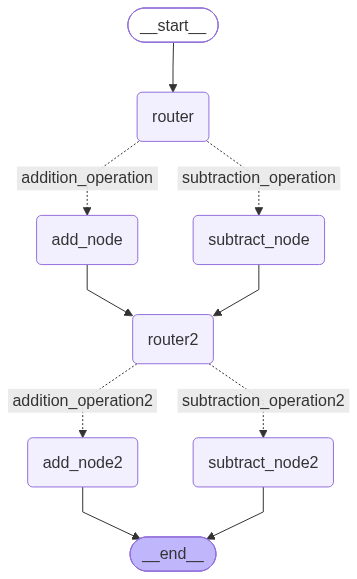

In [73]:
from IPython.display import display, Image
display(Image(app.get_graph().draw_mermaid_png()))

In [76]:
initial_state = AgentState(number1=10, number2=5, operation="-", number3=7, number4=2, operation2="+")
print(app.invoke(initial_state))

{'number1': 10, 'operation': '-', 'number2': 5, 'finalNumber': 5, 'number3': 7, 'operation2': '+', 'number4': 2, 'finalNumber2': 9}
